In [1]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from dotenv import load_dotenv

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

from typesafe_sdk import TypeSafeClient, Noul

/home/leonardo/Documentos/github/jev_laya_studies/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BATCH_SIZE = 32
THRESHOLD = 0.5

In [3]:
load_dotenv()

True

In [4]:
df = pd.read_csv("disaster_tweets.csv")

df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


In [6]:
df["target"].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

In [7]:
df["target"].value_counts(normalize=True)

target
0    0.57034
1    0.42966
Name: proportion, dtype: float64

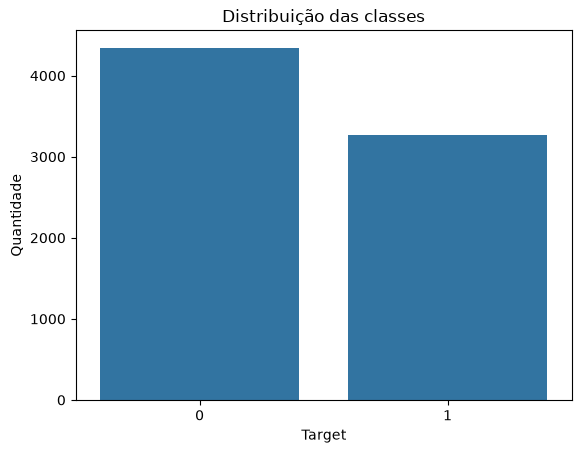

In [8]:
sns.countplot(
    data=df,
    x="target"
)

plt.title("Distribuição das classes")
plt.xlabel("Target")
plt.ylabel("Quantidade")
plt.show()

In [9]:
_, df_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["target"]
)

In [10]:
df_test = df_test.reset_index(drop=True)

print(df_test.shape)
df_test.head()

(1523, 5)


,id,keyword,location,text,target
0,6925,mass%20murderer,"Huntsville, AL",@TheEconomist Step one: get that mass murderer...,0
1,1975,bush%20fires,Queen Creek AZ,Ted Cruz fires back at Jeb &amp; Bush: ÛÏWe l...,0
2,5034,eyewitness,NaN,How ÛÏLittle BoyÛ Affected the People In Hi...,1
3,254,ambulance,Happily Married with 2 kids,AMBULANCE SPRINTER AUTOMATIC FRONTLINE VEHICLE...,0
4,8370,ruin,NaN,'Cause you play me like a symphony play me til...,0


In [11]:
N_SAMPLES = 200

In [12]:
df_eval, _ = train_test_split(
    df_test,
    train_size=N_SAMPLES,
    random_state=42,
    stratify=df_test["target"]
)

df_eval = df_eval.reset_index(drop=True)

In [13]:
def predict_batch(client, batch):
    
    # Transforma o DataFrame em um state estruturado
    state = {
        "tweets": [
            {
                "text": row["text"],
                "keyword": (
                    row["keyword"]
                    if pd.notna(row["keyword"])
                    else None
                ),
                "location": (
                    row["location"]
                    if pd.notna(row["location"])
                    else None
                ),
            }
            for _, row in batch.iterrows()
        ]
    }

    # Cria um Noul independente para cada tweet
    questions = {
        f"tweet_{i}": Noul(
            instructions=(
                f"Does `tweets[{i}].text` describe or report a real-world "
                "disaster or emergency event? "
                "Return yes for actual events such as fires, floods, earthquakes, "
                "storms, accidents, explosions, attacks, evacuations, casualties "
                "or similar emergencies. "
                "Return no when disaster-related language is metaphorical, "
                "figurative, humorous, promotional, fictional, or otherwise "
                "does not describe a real-world disaster or emergency."
            )
        )
        for i in range(len(batch))
    }

    # Faz uma única chamada ao Jev
    response = client.system_one(
        state=state,
        questions=questions,
    )

    # Extrai P(target=1)
    probabilities = [
        response.answers[f"tweet_{i}"].noul
        for i in range(len(batch))
    ]

    return probabilities

In [14]:
def predict_dataset(df, batch_size=32):
    
    probabilities = []

    with TypeSafeClient() as client:

        for start in tqdm(range(0, len(df), batch_size)):

            end = min(
                start + batch_size,
                len(df)
            )

            batch = df.iloc[start:end]

            batch_probabilities = predict_batch(
                client,
                batch
            )

            probabilities.extend(
                batch_probabilities
            )

            print(
                f"{end}/{len(df)} tweets classificados"
            )

    return np.array(probabilities)

In [15]:
y_score = predict_dataset(
    df_eval,
    batch_size=BATCH_SIZE
)

 14%|███▋                      | 1/7 [00:00<00:02,  2.72it/s]

32/200 tweets classificados


 29%|███████▍                  | 2/7 [00:00<00:01,  2.82it/s]

64/200 tweets classificados


 43%|███████████▏              | 3/7 [00:01<00:01,  3.07it/s]

...

160/200 tweets classificados


 86%|██████████████████████▎   | 6/7 [00:01<00:00,  3.33it/s]

192/200 tweets classificados


100%|██████████████████████████| 7/7 [00:02<00:00,  3.24it/s]

200/200 tweets classificados


In [16]:
y_score[:10]

array([0.97, 0.05, 0.1 , 0.92, 0.07, 0.4 , 0.94, 0.94, 0.07, 0.08])

In [17]:
y_pred = (
    y_score >= THRESHOLD
).astype(int)

In [18]:
y_true = df_eval["target"].to_numpy()

In [19]:
results = df_eval[
    [
        "id",
        "text",
        "target"
    ]
].copy()

results["jev_probability"] = y_score
results["jev_prediction"] = y_pred
results.head(20)

,id,text,target,jev_probability,jev_prediction
0,7498,Refugio oil spill may have been costlier bigge...,1,0.97,1
1,1475,8 hours of bagging groceries = an aching body,0,0.05,0
2,10658,@mattmosley post a pic of your wounds please,0,0.10,0
3,4139,Moderate #drought is spreading rapidly across ...,1,0.92,1
4,6682,'Since1970the 2 biggest depreciations in CAD:U...,0,0.07,0
5,4122,#weed news How marijuana is making California ...,1,0.40,0
6,10194,POV video captures violent landing at Amsterda...,1,0.94,1
7,9813,#NissanNews : Trauma Alert and 1 Child Among 6...,1,0.94,1
8,470,@RohnertParkDPS You're another one for the his...,0,0.07,0
9,54,@PhDSquares #mufc they've built so much hype a...,0,0.08,0


In [20]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

roc_auc = roc_auc_score(
    y_true,
    y_score
)

In [21]:
metrics = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC"
    ],
    "Valor": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

metrics

,Métrica,Valor
0,Accuracy,0.760000
1,Precision,0.763889
2,Recall,0.639535
3,F1,0.696203
4,ROC AUC,0.837311


In [22]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Não desastre",
            "Desastre"
        ]
    )
)

              precision    recall  f1-score   support

Não desastre       0.76      0.85      0.80       114
    Desastre       0.76      0.64      0.70        86

    accuracy                           0.76       200
   macro avg       0.76      0.75      0.75       200
weighted avg       0.76      0.76      0.76       200



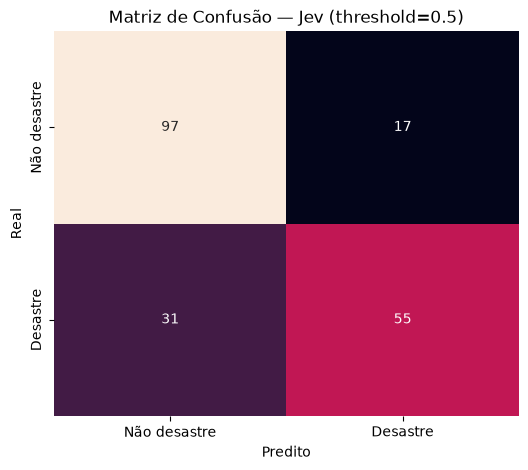

In [23]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=[
        "Não desastre",
        "Desastre"
    ],
    yticklabels=[
        "Não desastre",
        "Desastre"
    ],
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title(
    f"Matriz de Confusão — Jev (threshold={THRESHOLD})"
)

plt.show()

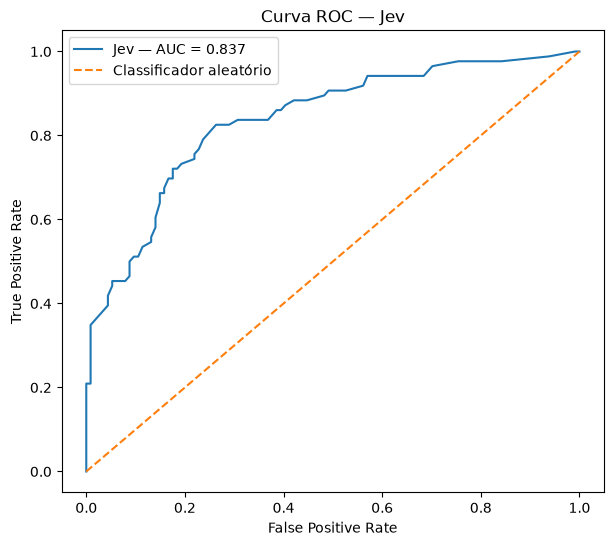

In [24]:
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_score
)

auc = roc_auc_score(
    y_true,
    y_score
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Jev — AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — Jev")
plt.legend()

plt.show()

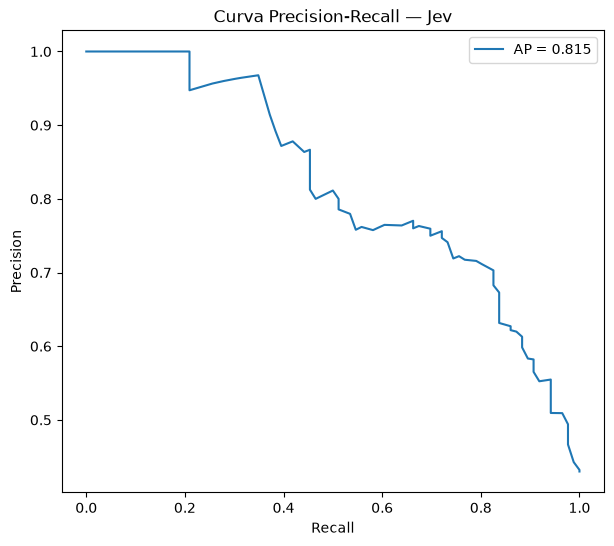

In [25]:
precision_curve, recall_curve, thresholds_pr = (
    precision_recall_curve(
        y_true,
        y_score
    )
)

average_precision = average_precision_score(
    y_true,
    y_score
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"AP = {average_precision:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — Jev")
plt.legend()

plt.show()

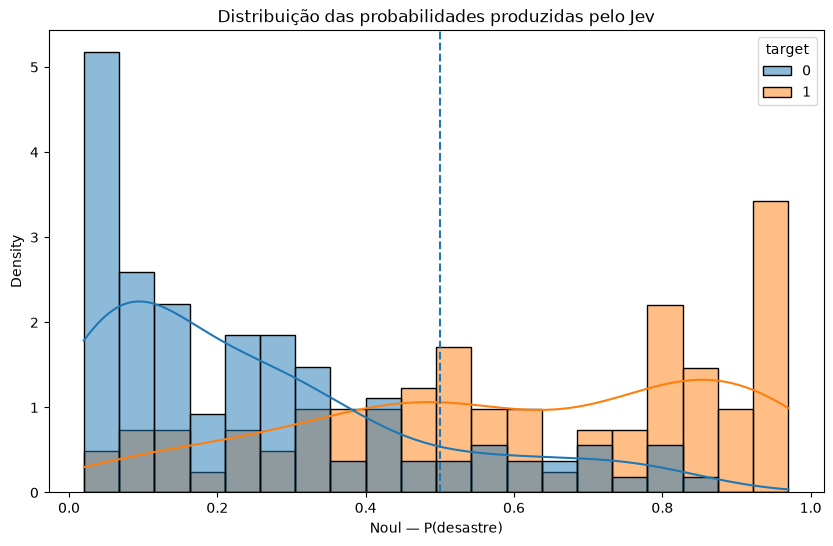

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=results,
    x="jev_probability",
    hue="target",
    bins=20,
    kde=True,
    stat="density",
    common_norm=False,
)

plt.axvline(
    THRESHOLD,
    linestyle="--"
)

plt.xlabel("Noul — P(desastre)")
plt.title(
    "Distribuição das probabilidades produzidas pelo Jev"
)

plt.show()

In [27]:
false_positives = results[
    (results["target"] == 0)
    &
    (results["jev_prediction"] == 1)
].sort_values(
    "jev_probability",
    ascending=False
)

false_positives[
    [
        "text",
        "target",
        "jev_probability"
    ]
].head(20)

,text,target,jev_probability
90,Hey #AZ: Sign this petition to save the #WildH...,0,0.87
88,@Homukami Only URs and SRs matter Rs you'll be...,0,0.79
86,@VictoriaGittins what do you take me for I'm n...,0,0.79
114,@Limpar33 sweeping legs? Or putting people in ...,0,0.78
62,OH. #TeamHennessy #NJ Obliteration @tprimo24 ...,0,0.77
61,@teamVODG Discovered by @NickCannon \n Listen/...,0,0.73
29,@Papcrdoll and I s2g if my mentions get blown ...,0,0.70
115,Loved the opener and still feeling guilty for ...,0,0.69
187,Sexual Revolution:Blight For Women is out! htt...,0,0.68
60,It's like God wants me to become a mass murder...,0,0.65


In [28]:
false_negatives = results[
    (results["target"] == 1)
    &
    (results["jev_prediction"] == 0)
].sort_values(
    "jev_probability"
)

false_negatives[
    [
        "text",
        "target",
        "jev_probability"
    ]
].head(20)

,text,target,jev_probability
192,you can stab me in the back but I promise you'...,1,0.03
167,That horrible sinking feeling when youÛªve be...,1,0.04
171,The Prophet (peace be upon him) said 'Save you...,1,0.07
139,Swansea Û÷plot hijack transfer move for South...,1,0.08
137,I just checked in! ÛÒ at On Fire on @ZomatoAU...,1,0.08
181,@Habbo bring back games from the past. Snowsto...,1,0.15
193,@115Film Doctor we must leave immediately the ...,1,0.15
170,Manuel hoping for an early Buffalo snowstorm s...,1,0.16
69,I liked a @YouTube video http://t.co/XO2ZbPBJB...,1,0.19
94,The Latest: More Homes Razed by Northern Calif...,1,0.21


In [29]:
thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

f1_scores = []

for threshold in thresholds:
    
    predictions = (
        y_score >= threshold
    ).astype(int)

    score = f1_score(
        y_true,
        predictions
    )

    f1_scores.append(score)

In [30]:
threshold_results = pd.DataFrame({
    "threshold": thresholds,
    "f1": f1_scores
})

In [31]:
best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

best_row

threshold    0.340000
f1           0.759358
Name: 29, dtype: float64

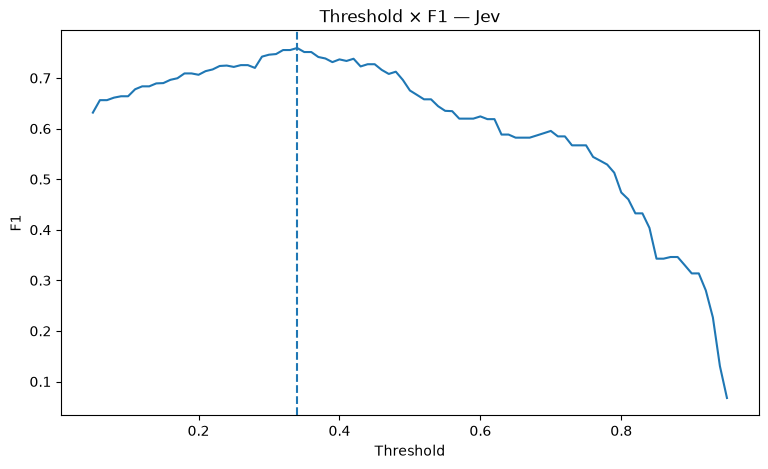

In [32]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=threshold_results,
    x="threshold",
    y="f1"
)

plt.axvline(
    best_row["threshold"],
    linestyle="--"
)

plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("Threshold × F1 — Jev")

plt.show()